# Optimización de hiperparámetros en árboles de decisión  
Por eso usaremos un dataset sintético generado con `make_classification`.



## 1. Importación de librerías

Este notebook no requiere archivos externos.

Todo se ejecuta directamente en Google Colab usando librerías estándar del ecosistema científico de Python.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    validation_curve,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 4)

## 2. Generación del dataset

Generaremos un problema de clasificación binaria con:

- 2500 observaciones;
- 10 variables predictoras;
- 5 variables informativas;
- 2 variables redundantes;
- 3 variables de ruido;
- cierto ruido en las etiquetas;
- separación moderada entre clases.

Esto produce un problema suficientemente desafiante para que un árbol sin restricciones pueda sobreajustar, pero no tan difícil como para que el modelo no aprenda nada.

### Diseño didáctico

El dataset fue elegido para que los hiperparámetros tengan efectos visibles.

En particular, buscamos que:

- árboles muy poco profundos subajusten;
- árboles intermedios funcionen mejor;
- árboles muy profundos tengan mayor desempeño en train, pero no necesariamente en validación/test.

In [2]:
X_array, y_array = make_classification(
    n_samples=2500,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=0.85,
    flip_y=0.08,
    weights=[0.58, 0.42],
    # Mantiene primero las 5 variables informativas, luego las 2 redundantes
    # y al final las 3 variables sin información. Así, las columnas llamadas
    # ruido_sensor_1 y ruido_sensor_2 son realmente variables de ruido.
    shuffle=False,
    random_state=RANDOM_STATE
)

feature_names = [
    "edad_equipo",
    "temperatura",
    "presion",
    "vibracion",
    "consumo",
    "humedad",
    "velocidad",
    "carga",
    "ruido_sensor_1",
    "ruido_sensor_2"
]

X = pd.DataFrame(X_array, columns=feature_names)
y = pd.Series(y_array, name="falla")

print("Dimensiones de X:", X.shape)
print("Distribución de clases:")
display(y.value_counts().rename(index={0: "normal", 1: "falla"}))
display(y.value_counts(normalize=True).rename(index={0: "normal", 1: "falla"}))

Dimensiones de X: (2500, 10)
Distribución de clases:


falla
normal    1436
falla     1064
Name: count, dtype: int64

falla
normal    0.5744
falla     0.4256
Name: proportion, dtype: float64

## 3. Contexto ficticio del problema

Para hacer el ejemplo más interpretable, imaginemos que se trata de un problema de mantenimiento predictivo.

Cada observación corresponde a una máquina o equipo industrial.

Queremos predecir si el equipo presentará una falla:

- `0`: funcionamiento normal;
- `1`: falla.

Las variables tienen nombres realistas, aunque el dataset es sintético.

Esto permite concentrarse en el proceso de modelado sin depender de un archivo externo.

In [3]:
display(X.head())
display(X.describe().T)

,edad_equipo,temperatura,presion,vibracion,consumo,humedad,velocidad,carga,ruido_sensor_1,ruido_sensor_2
0,2.333743,-0.028123,-1.067597,-0.484211,-0.511199,1.115000,-2.527075,-1.280977,-1.004112,0.632819
1,-0.348684,4.013014,-0.731355,-1.130632,3.650602,-0.877361,2.189600,-0.509790,-1.107925,0.754014
2,1.334195,2.617542,-0.447219,-0.149292,2.420110,0.960413,0.418827,0.128972,-2.363666,0.995624
3,1.474752,0.149554,1.346178,-0.784105,0.062360,-0.681680,-2.260508,0.072073,0.770374,-0.225222
4,2.523446,4.357356,4.019924,0.336960,3.779822,-0.401786,-0.958237,1.604691,-0.381889,-2.635839


,count,mean,std,min,25%,50%,75%,max
edad_equipo,2500.0,0.485779,1.684126,-5.722051,-0.587211,0.546869,1.592756,7.667943
temperatura,2500.0,0.498636,1.492028,-4.494483,-0.464679,0.547940,1.476820,4.873009
presion,2500.0,-0.031968,1.800812,-6.074842,-1.225735,0.126955,1.237959,5.759674
vibracion,2500.0,-0.491997,1.271057,-5.322883,-1.389646,-0.577666,0.328746,4.033470
consumo,2500.0,0.360854,1.442979,-4.657066,-0.571308,0.414000,1.367544,4.943023
humedad,2500.0,-0.246213,1.727322,-5.782258,-1.300514,-0.173794,0.710065,5.020685
velocidad,2500.0,-0.536829,2.549644,-9.893743,-2.104505,-0.455808,1.071045,8.945409
carga,2500.0,0.037680,0.979653,-4.064603,-0.644051,0.045823,0.719369,3.777490
ruido_sensor_1,2500.0,0.030287,1.014041,-3.540961,-0.672836,0.044408,0.734934,3.556458
ruido_sensor_2,2500.0,0.008325,1.022587,-4.019121,-0.688332,0.009439,0.675890,3.513676


## 4. Partición train/test

Reservamos un conjunto de test para la evaluación final.

Toda la selección de hiperparámetros se hará usando solamente el conjunto de entrenamiento mediante validación cruzada.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print()
print("Proporción de fallas en train:", y_train.mean().round(3))
print("Proporción de fallas en test :", y_test.mean().round(3))

Train: (1875, 10)
Test : (625, 10)

Proporción de fallas en train: 0.426
Proporción de fallas en test : 0.426


## 5. Árbol sin restricciones

Primero entrenamos un árbol sin limitar su crecimiento.

Este modelo sirve como referencia para observar sobreajuste.

In [5]:
tree_default = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

tree_default.fit(X_train, y_train)

pred_train_default = tree_default.predict(X_train)
pred_test_default = tree_default.predict(X_test)

print("Árbol sin restricciones")
print("-" * 40)
print(f"Accuracy train          : {accuracy_score(y_train, pred_train_default):.3f}")
print(f"Accuracy test           : {accuracy_score(y_test, pred_test_default):.3f}")
print(f"Balanced accuracy test  : {balanced_accuracy_score(y_test, pred_test_default):.3f}")
print(f"F1 test                 : {f1_score(y_test, pred_test_default):.3f}")
print(f"Profundidad             : {tree_default.get_depth()}")
print(f"Número de hojas         : {tree_default.get_n_leaves()}")

Árbol sin restricciones
----------------------------------------
Accuracy train          : 1.000
Accuracy test           : 0.757
Balanced accuracy test  : 0.746
F1 test                 : 0.703
Profundidad             : 18
Número de hojas         : 242


### Interpretación

Un árbol sin restricciones suele obtener desempeño perfecto o casi perfecto en entrenamiento.

Eso no significa que sea el mejor modelo.

Puede haber aprendido reglas demasiado específicas del conjunto de entrenamiento.

La selección de hiperparámetros busca controlar esta complejidad.

## 6. Validación cruzada y métrica

Usaremos validación cruzada estratificada con 5 folds.

La métrica principal será `balanced_accuracy`.

¿Por qué?

Porque mide el promedio entre sensibilidad para la clase 0 y sensibilidad para la clase 1.  
Es útil cuando queremos evitar que el modelo favorezca demasiado una clase.

También podríamos usar `f1`, pero para este ejemplo `balanced_accuracy` suele producir una lectura más estable de la curva de complejidad.

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = "balanced_accuracy"

## 7. Curva de validación para `max_depth`

Primero analizamos un solo hiperparámetro: `max_depth`.

Esto permite ver cómo cambia el desempeño al aumentar la profundidad máxima del árbol.

Esperamos observar algo como:

- baja profundidad: subajuste;
- profundidad intermedia: mejor validación;
- profundidad alta: mayor train, pero validación se estabiliza o cae.

,max_depth,train_mean,valid_mean,valid_std
6,8,0.889330,0.771003,0.009980
5,6,0.831633,0.766977,0.026001
4,5,0.817626,0.766707,0.022160
3,4,0.788425,0.754478,0.024477
10,20,1.000000,0.754396,0.016043
11,None,1.000000,0.754396,0.016043
7,10,0.932355,0.753574,0.029038
8,12,0.960528,0.751731,0.010797
9,16,0.996663,0.750819,0.010020
1,2,0.741093,0.725882,0.008686


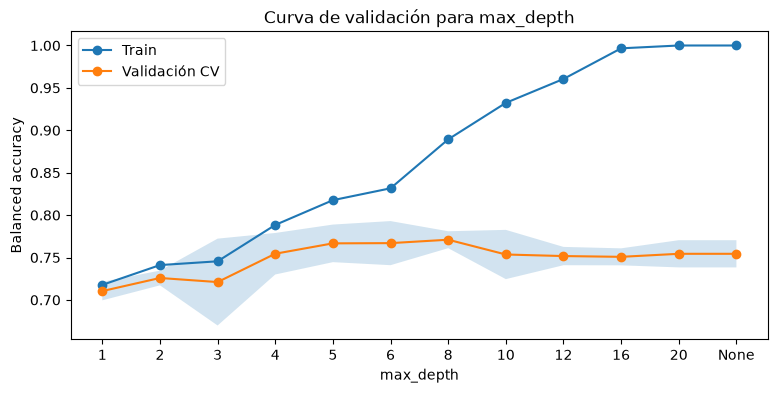

In [7]:
depth_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, None]

train_scores_depth, valid_scores_depth = validation_curve(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=depth_values,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1
)

depth_labels = [str(d) for d in depth_values]

depth_results = pd.DataFrame({
    "max_depth": depth_labels,
    "train_mean": train_scores_depth.mean(axis=1),
    "valid_mean": valid_scores_depth.mean(axis=1),
    "valid_std": valid_scores_depth.std(axis=1)
})

display(depth_results.sort_values("valid_mean", ascending=False))

plt.figure(figsize=(9, 4))
plt.plot(depth_labels, train_scores_depth.mean(axis=1), marker="o", label="Train")
plt.plot(depth_labels, valid_scores_depth.mean(axis=1), marker="o", label="Validación CV")
plt.fill_between(
    depth_labels,
    valid_scores_depth.mean(axis=1) - valid_scores_depth.std(axis=1),
    valid_scores_depth.mean(axis=1) + valid_scores_depth.std(axis=1),
    alpha=0.2
)
plt.xlabel("max_depth")
plt.ylabel("Balanced accuracy")
plt.title("Curva de validación para max_depth")
plt.legend()
plt.show()

### Lectura de la curva

Esta curva permite discutir tres regiones:

1. **Subajuste**  
   El árbol es demasiado simple. Train y validación son bajos.

2. **Zona razonable**  
   La validación mejora y el árbol todavía no es excesivamente complejo.

3. **Sobreajuste**  
   El desempeño en train sigue aumentando, pero validación se estabiliza o empeora.

Sin embargo, esta curva analiza solo un hiperparámetro.

La complejidad real del árbol también depende de otros parámetros.

## 8. Interacción entre `max_depth` y `min_samples_leaf`

Ahora analizamos dos hiperparámetros en conjunto.

`max_depth` limita la profundidad máxima.  
`min_samples_leaf` exige una cantidad mínima de observaciones en cada hoja.

Estos hiperparámetros interactúan:

- un árbol profundo con hojas de tamaño 1 puede sobreajustar;
- un árbol profundo con hojas grandes puede ser más estable;
- un árbol poco profundo con hojas grandes puede subajustar.

In [8]:
param_grid_2d = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50]
}

grid_2d = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid_2d,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True
)

grid_2d.fit(X_train, y_train)

results_2d = pd.DataFrame(grid_2d.cv_results_)

display(
    results_2d[
        [
            "param_max_depth",
            "param_min_samples_leaf",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score").head(15)
)


,param_max_depth,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
40,10,20,0.837420,0.792602,0.009560,1
46,None,20,0.841083,0.791148,0.010803,2
34,8,20,0.830263,0.790459,0.019248,3
39,10,10,0.857390,0.782225,0.017969,4
45,None,10,0.868608,0.777098,0.011033,5
33,8,10,0.845591,0.776985,0.011466,6
28,6,20,0.805355,0.773755,0.024926,7
26,6,5,0.824650,0.773270,0.027572,8
22,5,20,0.800198,0.772985,0.031024,9
20,5,5,0.815698,0.772182,0.026171,10


### Idea central

Esta tabla muestra por qué no conviene optimizar `max_depth` de manera aislada.

La mejor profundidad puede depender del tamaño mínimo permitido para las hojas.

Por eso, en la práctica se usan grillas conjuntas.

## 9. Estrategia 1: búsqueda de pre-poda

La pre-poda evita que el árbol crezca demasiado desde el inicio.

Usaremos una grilla con:

- `max_depth`
- `min_samples_leaf`
- `min_samples_split`
- `max_leaf_nodes`

`max_leaf_nodes` limita directamente la cantidad máxima de hojas.  
Es útil cuando queremos árboles interpretables.

In [9]:
param_grid_prepoda = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "min_samples_split": [2, 5, 10, 20, 50],
    "max_leaf_nodes": [None, 10, 20, 40, 80]
}

grid_prepoda = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid_prepoda,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True
)

grid_prepoda.fit(X_train, y_train)

results_prepoda = pd.DataFrame(grid_prepoda.cv_results_).sort_values("rank_test_score")

display(
    results_prepoda[
        [
            "param_max_depth",
            "param_min_samples_leaf",
            "param_min_samples_split",
            "param_max_leaf_nodes",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].head(20)
)

print("Mejores hiperparámetros de pre-poda:")
print(grid_prepoda.best_params_)
print(f"Mejor balanced accuracy CV: {grid_prepoda.best_score_:.3f}")

,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_max_leaf_nodes,mean_train_score,mean_test_score,std_test_score,rank_test_score
830,10,20,2,20,0.833728,0.798628,0.020296,1
833,10,20,20,20,0.833728,0.798628,0.020296,1
832,10,20,10,20,0.833728,0.798628,0.020296,1
831,10,20,5,20,0.833728,0.798628,0.020296,1
834,10,20,50,20,0.831950,0.798495,0.022216,5
824,10,5,50,20,0.840448,0.797258,0.018236,6
810,10,1,2,20,0.843561,0.797139,0.017853,7
811,10,1,5,20,0.843561,0.797139,0.017853,7
812,10,1,10,20,0.843561,0.797139,0.017853,7
817,10,2,10,20,0.843561,0.797139,0.017853,7


Mejores hiperparámetros de pre-poda:
{'max_depth': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mejor balanced accuracy CV: 0.799


## 10. Post-poda con `ccp_alpha`

La post-poda funciona de otra forma:

1. Se deja crecer un árbol.
2. Luego se eliminan ramas que no justifican su complejidad.
3. `ccp_alpha` controla cuánta complejidad se penaliza.

Valores pequeños de `ccp_alpha` generan árboles grandes.  
Valores altos generan árboles más simples.

In [10]:
tree_for_path = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

path = tree_for_path.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

print("Cantidad de valores candidatos de ccp_alpha:", len(ccp_alphas))
print("Primeros valores:")
print(ccp_alphas[:10])

Cantidad de valores candidatos de ccp_alpha: 117
Primeros valores:
[0.         0.00045714 0.00048    0.00048485 0.00048485 0.0005
 0.0005037  0.00050667 0.00051111 0.00051343]


In [11]:
# Tomamos valores representativos para que el notebook sea rápido.
if len(ccp_alphas) > 60:
    selected_alphas = np.unique(np.quantile(ccp_alphas, np.linspace(0, 0.98, 60)))
else:
    selected_alphas = ccp_alphas

selected_alphas = np.unique(np.concatenate([[0.0], selected_alphas]))

print("Cantidad de alphas evaluados:", len(selected_alphas))

Cantidad de alphas evaluados: 57


In [12]:
pruning_rows = []

for alpha in selected_alphas:
    model = DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE,
        ccp_alpha=alpha
    )

    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pruning_rows.append({
        "ccp_alpha": alpha,
        "train_mean": cv_result["train_score"].mean(),
        "valid_mean": cv_result["test_score"].mean(),
        "valid_std": cv_result["test_score"].std(),
        "depth": model.get_depth(),
        "n_leaves": model.get_n_leaves()
    })

pruning_results = pd.DataFrame(pruning_rows)

display(pruning_results.sort_values("valid_mean", ascending=False).head(15))

best_alpha_row = pruning_results.sort_values(
    ["valid_mean", "depth", "n_leaves"],
    ascending=[False, True, True]
).iloc[0]

best_alpha = best_alpha_row["ccp_alpha"]

print(f"Mejor ccp_alpha según CV: {best_alpha:.8f}")

,ccp_alpha,train_mean,valid_mean,valid_std,depth,n_leaves
50,0.002500,0.859437,0.791554,0.019121,9,21
52,0.003900,0.828604,0.790151,0.013674,7,16
49,0.002196,0.883644,0.787252,0.018452,9,23
51,0.002598,0.851886,0.787132,0.020321,7,17
53,0.004592,0.824706,0.786724,0.016108,7,14
44,0.001782,0.904631,0.786020,0.015324,13,46
48,0.002041,0.887828,0.785693,0.018145,9,26
45,0.001814,0.901427,0.785075,0.014700,13,38
47,0.001968,0.889370,0.785029,0.017134,10,29
46,0.001905,0.892020,0.784704,0.015420,12,35


Mejor ccp_alpha según CV: 0.00250002


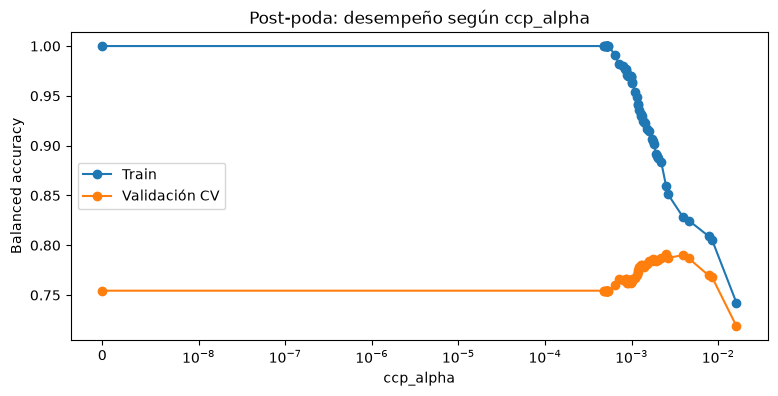

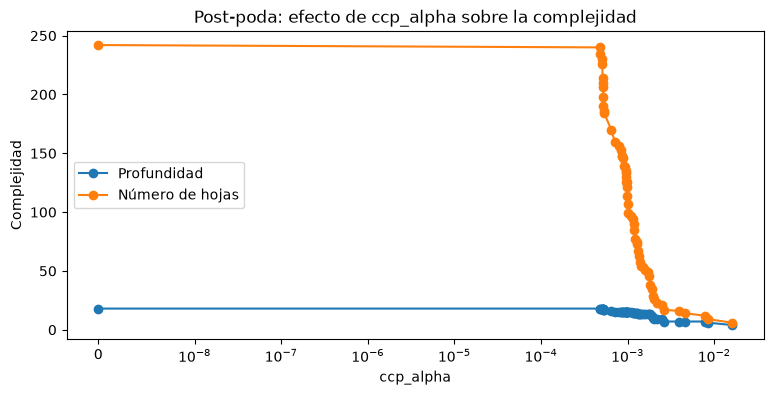

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(pruning_results["ccp_alpha"], pruning_results["train_mean"], marker="o", label="Train")
plt.plot(pruning_results["ccp_alpha"], pruning_results["valid_mean"], marker="o", label="Validación CV")
plt.xscale("symlog", linthresh=1e-8)
plt.xlabel("ccp_alpha")
plt.ylabel("Balanced accuracy")
plt.title("Post-poda: desempeño según ccp_alpha")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(pruning_results["ccp_alpha"], pruning_results["depth"], marker="o", label="Profundidad")
plt.plot(pruning_results["ccp_alpha"], pruning_results["n_leaves"], marker="o", label="Número de hojas")
plt.xscale("symlog", linthresh=1e-8)
plt.xlabel("ccp_alpha")
plt.ylabel("Complejidad")
plt.title("Post-poda: efecto de ccp_alpha sobre la complejidad")
plt.legend()
plt.show()

## 11. Búsqueda conjunta con pre-poda y post-poda

Ahora combinamos ambas estrategias.

No conviene hacer una grilla enorme, porque el costo crece rápidamente.

Usaremos:

- `max_depth`
- `min_samples_leaf`
- `min_samples_split`
- `max_leaf_nodes`
- `ccp_alpha`

Para `ccp_alpha`, usamos valores derivados de la ruta de poda.

In [14]:
candidate_alphas = np.unique(
    np.quantile(selected_alphas, q=[0.0, 0.25, 0.50, 0.75, 0.90])
)
candidate_alphas = np.unique(np.concatenate([[0.0], candidate_alphas]))

print("ccp_alpha candidatos para búsqueda conjunta:")
print(candidate_alphas)

ccp_alpha candidatos para búsqueda conjunta:
[0.         0.0008     0.00100626 0.0015768  0.00253903]


In [15]:
param_grid_conjunta = {
    "max_depth": [4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "max_leaf_nodes": [None, 10, 20, 40, 80],
    "ccp_alpha": candidate_alphas
}

grid_conjunta = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid_conjunta,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True
)

grid_conjunta.fit(X_train, y_train)

results_conjunta = pd.DataFrame(grid_conjunta.cv_results_).sort_values("rank_test_score")

display(
    results_conjunta[
        [
            "param_max_depth",
            "param_min_samples_leaf",
            "param_min_samples_split",
            "param_max_leaf_nodes",
            "param_ccp_alpha",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].head(20)
)

print("Mejor combinación conjunta:")
print(grid_conjunta.best_params_)
print(f"Mejor balanced accuracy CV: {grid_conjunta.best_score_:.3f}")

,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_max_leaf_nodes,param_ccp_alpha,mean_train_score,mean_test_score,std_test_score,rank_test_score
1656,10,20,2,20,0.001006,0.833728,0.798628,0.020296,1
1659,10,20,20,20,0.001006,0.833728,0.798628,0.020296,1
2259,10,20,20,20,0.001577,0.833728,0.798628,0.020296,1
1658,10,20,10,20,0.001006,0.833728,0.798628,0.020296,1
459,10,20,20,20,0.000000,0.833728,0.798628,0.020296,1
458,10,20,10,20,0.000000,0.833728,0.798628,0.020296,1
457,10,20,5,20,0.000000,0.833728,0.798628,0.020296,1
456,10,20,2,20,0.000000,0.833728,0.798628,0.020296,1
2258,10,20,10,20,0.001577,0.833728,0.798628,0.020296,1
2257,10,20,5,20,0.001577,0.833728,0.798628,0.020296,1


Mejor combinación conjunta:
{'ccp_alpha': np.float64(0.0), 'max_depth': 10, 'max_leaf_nodes': 20, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mejor balanced accuracy CV: 0.799


## 12. Criterio de simplicidad

Cuando varios modelos tienen desempeños similares, no siempre conviene elegir automáticamente el primer puesto.

Una estrategia razonable es elegir un modelo más simple dentro de una zona de desempeño aceptable.

Usaremos una aproximación de la regla de una desviación estándar:

1. Encontramos el mejor desempeño promedio en CV.
2. Calculamos el umbral: mejor media menos un error estándar (desviación entre folds dividida por la raíz del número de folds).
3. Consideramos aceptables los modelos por encima de ese umbral.
4. Elegimos el más simple entre ellos.

In [16]:
candidate_rows = []

for _, row in results_conjunta.iterrows():
    params = {
        "max_depth": row["param_max_depth"],
        "min_samples_leaf": row["param_min_samples_leaf"],
        "min_samples_split": row["param_min_samples_split"],
        "max_leaf_nodes": row["param_max_leaf_nodes"],
        "ccp_alpha": row["param_ccp_alpha"]
    }

    model = DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE,
        **params
    )
    model.fit(X_train, y_train)

    candidate_rows.append({
        **params,
        "mean_cv": row["mean_test_score"],
        "std_cv": row["std_test_score"],
        "rank": row["rank_test_score"],
        "depth": model.get_depth(),
        "n_leaves": model.get_n_leaves()
    })

candidate_table = pd.DataFrame(candidate_rows)

best_idx = candidate_table["mean_cv"].idxmax()
best_mean = candidate_table.loc[best_idx, "mean_cv"]
best_std = candidate_table.loc[best_idx, "std_cv"]
best_se = best_std / np.sqrt(cv.get_n_splits())
threshold = best_mean - best_se

simple_candidates = candidate_table[
    candidate_table["mean_cv"] >= threshold
].sort_values(
    ["depth", "n_leaves", "mean_cv"],
    ascending=[True, True, False]
)

print(f"Mejor balanced accuracy medio en CV: {best_mean:.3f}")
print(f"Desviación estándar entre folds: {best_std:.3f}")
print(f"Error estándar: {best_se:.3f}")
print(f"Umbral 1-SE: {threshold:.3f}")
print(f"Cantidad de modelos dentro del umbral: {len(simple_candidates)}")

display(simple_candidates.head(15))

selected_row = simple_candidates.iloc[0]

def as_optional_int(value):
    # Pandas convierte columnas con enteros y None en float/NaN.
    return None if pd.isna(value) else int(value)

selected_simple_params = {
    "max_depth": as_optional_int(selected_row["max_depth"]),
    "min_samples_leaf": int(selected_row["min_samples_leaf"]),
    "min_samples_split": int(selected_row["min_samples_split"]),
    "max_leaf_nodes": as_optional_int(selected_row["max_leaf_nodes"]),
    "ccp_alpha": float(selected_row["ccp_alpha"])
}

print("Modelo elegido por simplicidad:")
print(selected_simple_params)

Mejor balanced accuracy medio en CV: 0.799
Desviación estándar entre folds: 0.020
Error estándar: 0.009
Umbral 1-SE: 0.790
Cantidad de modelos dentro del umbral: 525


,max_depth,min_samples_leaf,min_samples_split,max_leaf_nodes,ccp_alpha,mean_cv,std_cv,rank,depth,n_leaves
179,8.0,20,10,40.0,0.002539,0.79392,0.023644,180,7,16
180,8.0,20,20,NaN,0.002539,0.79392,0.023644,180,7,16
181,8.0,20,10,NaN,0.002539,0.79392,0.023644,180,7,16
182,8.0,20,5,20.0,0.002539,0.79392,0.023644,180,7,16
183,8.0,20,20,40.0,0.002539,0.79392,0.023644,180,7,16
184,8.0,20,10,20.0,0.002539,0.79392,0.023644,180,7,16
185,8.0,20,20,20.0,0.002539,0.79392,0.023644,180,7,16
186,8.0,20,2,80.0,0.002539,0.79392,0.023644,180,7,16
187,8.0,20,5,NaN,0.002539,0.79392,0.023644,180,7,16
188,8.0,20,2,NaN,0.002539,0.79392,0.023644,180,7,16


Modelo elegido por simplicidad:
{'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 10, 'max_leaf_nodes': 40, 'ccp_alpha': 0.0025390341647727314}


## 13. Comparación final de estrategias

Comparamos:

1. Árbol sin restricciones.
2. Mejor modelo por pre-poda.
3. Mejor modelo solo con post-poda.
4. Mejor modelo de búsqueda conjunta.
5. Modelo simple dentro del umbral 1-SE.

La evaluación final se hace en el conjunto de test.

In [17]:
models = {
    "Default": DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ),
    "Pre-poda": grid_prepoda.best_estimator_,
    "Solo post-poda": DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE,
        ccp_alpha=best_alpha
    ),
    "Búsqueda conjunta": grid_conjunta.best_estimator_,
    "Simple 1-SE": DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE,
        **selected_simple_params
    )
}

comparison_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    comparison_rows.append({
        "modelo": name,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "balanced_accuracy_train": balanced_accuracy_score(y_train, pred_train),
        "balanced_accuracy_test": balanced_accuracy_score(y_test, pred_test),
        "f1_train": f1_score(y_train, pred_train),
        "f1_test": f1_score(y_test, pred_test),
        "depth": model.get_depth(),
        "n_leaves": model.get_n_leaves()
    })

comparison = pd.DataFrame(comparison_rows).sort_values(
    ["balanced_accuracy_test", "depth", "n_leaves"],
    ascending=[False, True, True]
)

display(comparison)

,modelo,accuracy_train,accuracy_test,balanced_accuracy_train,balanced_accuracy_test,f1_train,f1_test,depth,n_leaves
4,Simple 1-SE,0.840533,0.8224,0.837815,0.818622,0.813939,0.791745,7,16
1,Pre-poda,0.852267,0.8112,0.844783,0.800595,0.820712,0.766798,10,20
3,Búsqueda conjunta,0.852267,0.8112,0.844783,0.800595,0.820712,0.766798,10,20
2,Solo post-poda,0.853333,0.8032,0.849931,0.798500,0.827586,0.768362,9,21
0,Default,1.000000,0.7568,1.000000,0.746424,1.000000,0.703125,18,242


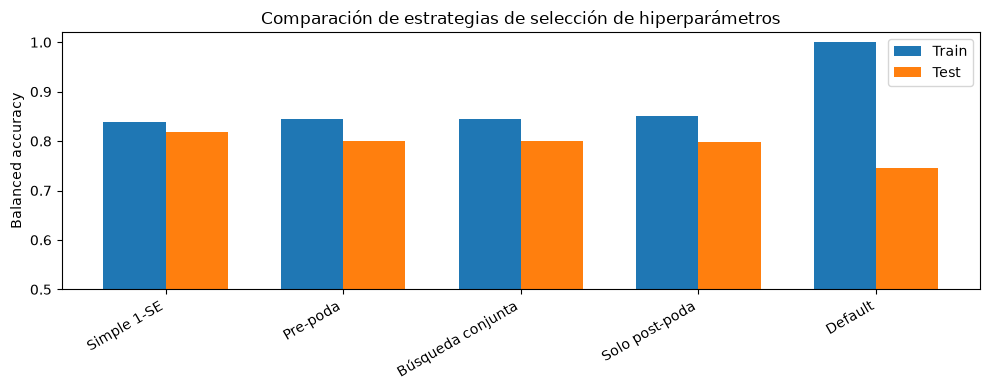

In [18]:
plt.figure(figsize=(10, 4))
x = np.arange(len(comparison))
width = 0.35

plt.bar(x - width/2, comparison["balanced_accuracy_train"], width, label="Train")
plt.bar(x + width/2, comparison["balanced_accuracy_test"], width, label="Test")

plt.xticks(x, comparison["modelo"], rotation=30, ha="right")
plt.ylim(0.50, 1.02)
plt.ylabel("Balanced accuracy")
plt.title("Comparación de estrategias de selección de hiperparámetros")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Evaluación del modelo final

Para fines didácticos, usaremos el modelo `Simple 1-SE`.

La idea es mostrar que la selección de modelos no debe depender solamente de una diferencia mínima en la métrica.

En árboles de decisión, un modelo algo más simple puede ser preferible si mantiene desempeño similar.

              precision    recall  f1-score   support

      normal       0.85      0.84      0.85       359
       falla       0.79      0.79      0.79       266

    accuracy                           0.82       625
   macro avg       0.82      0.82      0.82       625
weighted avg       0.82      0.82      0.82       625



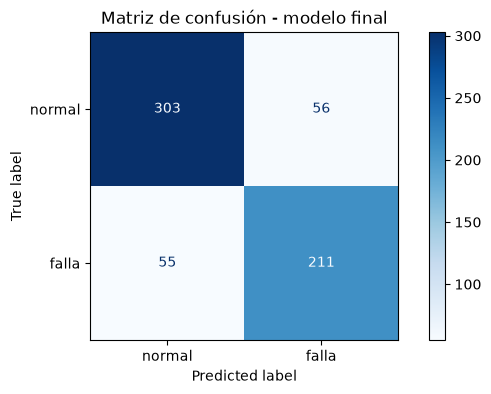

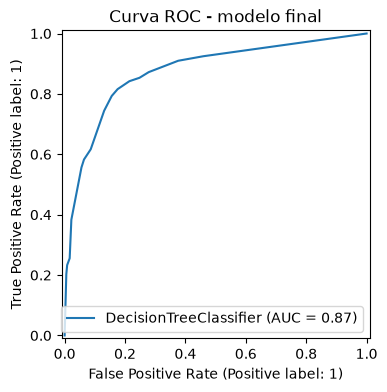

Parámetros del modelo final:
{'ccp_alpha': 0.0025390341647727314, 'class_weight': None, 'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'max_leaf_nodes': 40, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 20, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Profundidad: 7
Número de hojas: 16


In [19]:
final_model = models["Simple 1-SE"]
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=["normal", "falla"]
))

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    display_labels=["normal", "falla"],
    cmap="Blues"
)
plt.title("Matriz de confusión - modelo final")
plt.show()

RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)
plt.title("Curva ROC - modelo final")
plt.show()

print("Parámetros del modelo final:")
print(final_model.get_params())
print()
print(f"Profundidad: {final_model.get_depth()}")
print(f"Número de hojas: {final_model.get_n_leaves()}")

## 15. Visualización del árbol final

Una ventaja de los árboles de decisión es que pueden visualizarse.

Si el árbol es grande, se puede limitar la visualización usando `max_depth` dentro de `plot_tree`.

Esto no modifica el modelo, solo limita lo que se muestra.

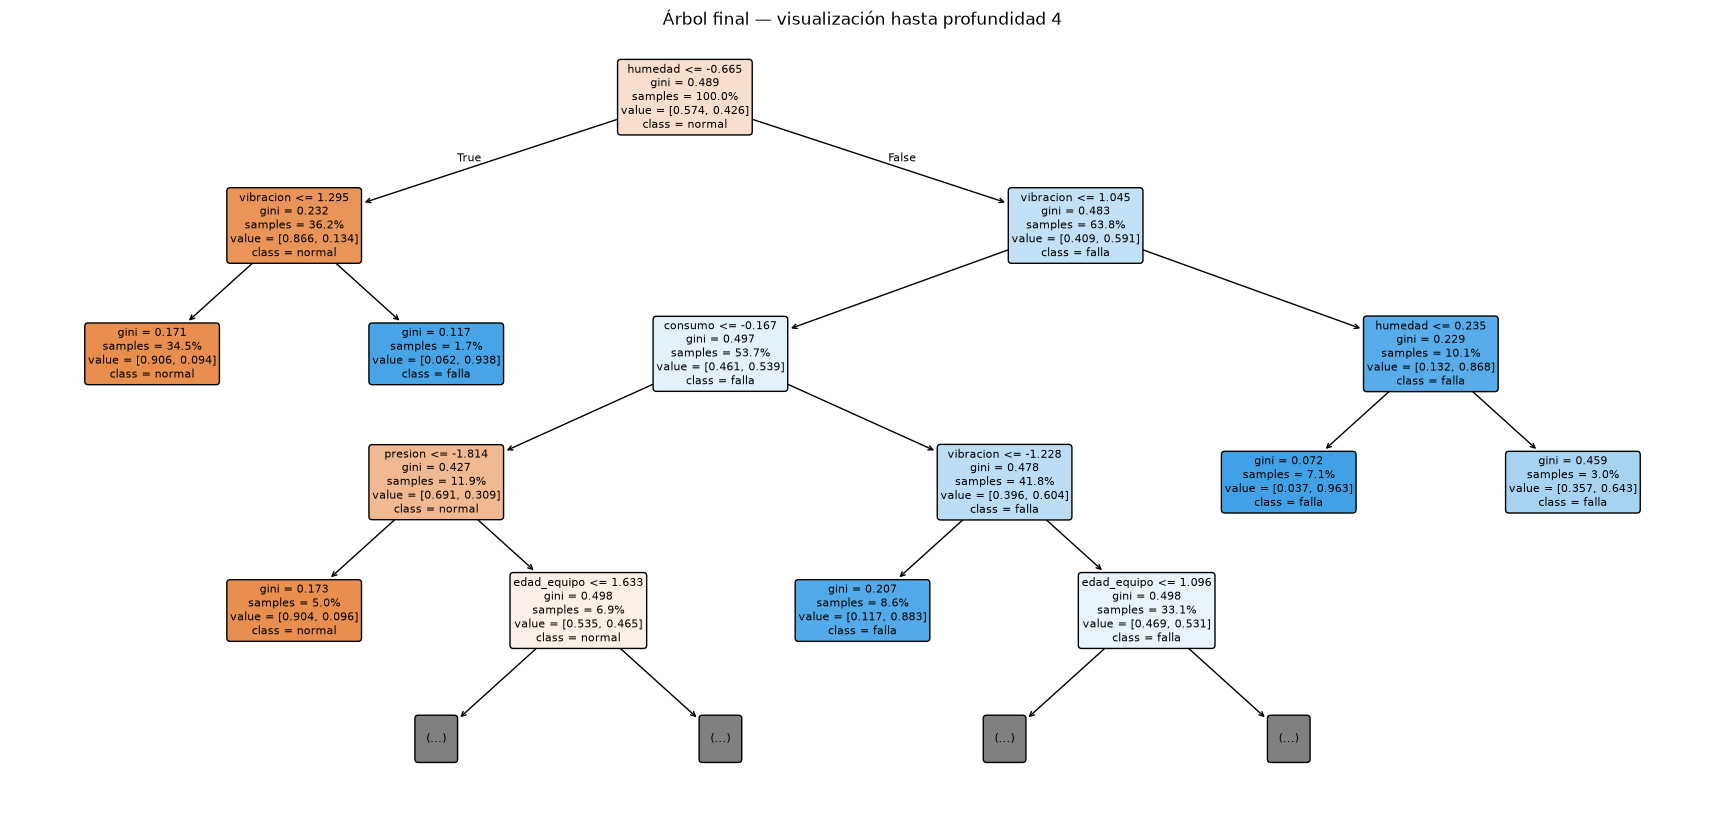

In [20]:
plt.figure(figsize=(22, 10))

plot_tree(
    final_model,
    feature_names=list(X_train.columns),
    class_names=["normal", "falla"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=8,
    max_depth=4
)

plt.title("Árbol final — visualización hasta profundidad 4")
plt.show()

## 16. Reglas textuales

También podemos imprimir el árbol como reglas.

Esto es útil para conectar el árbol con condiciones tipo `if/else`.

In [21]:
rules = export_text(
    final_model,
    feature_names=list(X_train.columns),
    max_depth=4,
    decimals=3
)

print(rules)

|--- humedad <= -0.665
|   |--- vibracion <= 1.295
|   |   |--- class: 0
|   |--- vibracion >  1.295
|   |   |--- class: 1
|--- humedad >  -0.665
|   |--- vibracion <= 1.045
|   |   |--- consumo <= -0.167
|   |   |   |--- presion <= -1.814
|   |   |   |   |--- class: 0
|   |   |   |--- presion >  -1.814
|   |   |   |   |--- edad_equipo <= 1.633
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- edad_equipo >  1.633
|   |   |   |   |   |--- class: 0
|   |   |--- consumo >  -0.167
|   |   |   |--- vibracion <= -1.228
|   |   |   |   |--- class: 1
|   |   |   |--- vibracion >  -1.228
|   |   |   |   |--- edad_equipo <= 1.096
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- edad_equipo >  1.096
|   |   |   |   |   |--- truncated branch of depth 3
|   |--- vibracion >  1.045
|   |   |--- humedad <= 0.235
|   |   |   |--- class: 1
|   |   |--- humedad >  0.235
|   |   |   |--- class: 1



## 17. Importancia de variables

La importancia de variables en árboles se basa en la reducción de impureza.

Debe interpretarse con cuidado:

- no implica causalidad;
- puede verse afectada por variables correlacionadas;
- depende del modelo entrenado;
- variables de ruido pueden aparecer con alguna importancia si el árbol sobreajusta.

,feature,importance
5,humedad,0.454315
3,vibracion,0.279392
0,edad_equipo,0.081218
4,consumo,0.078919
1,temperatura,0.074905
2,presion,0.031251
6,velocidad,0.000000
7,carga,0.000000
8,ruido_sensor_1,0.000000
9,ruido_sensor_2,0.000000


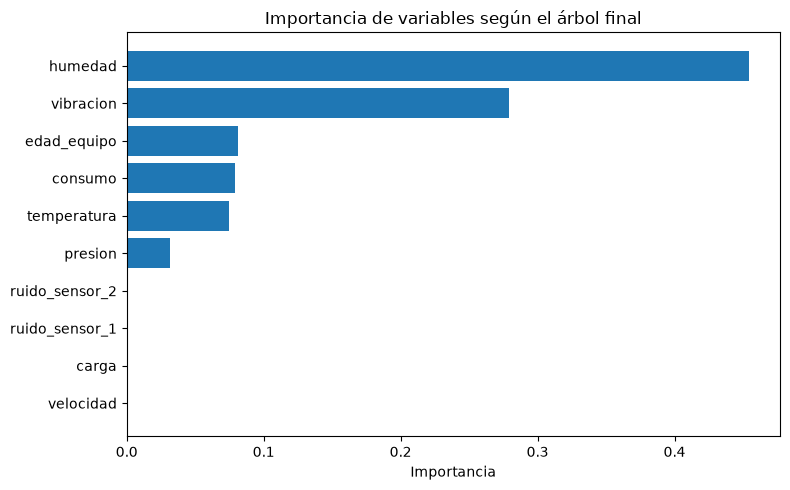

In [22]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance.sort_values("importance")["feature"],
    feature_importance.sort_values("importance")["importance"]
)
plt.xlabel("Importancia")
plt.title("Importancia de variables según el árbol final")
plt.tight_layout()
plt.show()

## 18. Análisis de errores

Mirar ejemplos mal clasificados ayuda a conectar las métricas con casos concretos.

In [23]:
error_mask = y_test != y_pred

errors = X_test[error_mask].copy()
errors["real"] = y_test[error_mask]
errors["predicho"] = y_pred[error_mask]

print("Cantidad de errores:", errors.shape[0])
display(errors.head(10))

Cantidad de errores: 111


,edad_equipo,temperatura,presion,vibracion,consumo,humedad,velocidad,carga,ruido_sensor_1,ruido_sensor_2,real,predicho
1719,0.998526,-1.018182,-0.239378,-1.188683,1.709125,1.549037,0.099963,-0.514478,-0.795955,-0.720102,0,1
1312,-0.864775,-0.728307,-2.825429,0.039041,1.173573,2.446921,2.900307,0.503237,0.450222,-0.437618,0,1
2396,0.589022,-1.086147,-2.544536,-1.058857,-0.450883,1.066853,-0.570967,-1.540821,0.232429,0.715043,1,0
481,0.300011,1.503731,1.528482,0.038867,2.757436,0.482575,1.361046,-1.232358,-0.610765,0.817237,0,1
639,1.306444,-0.050529,3.471842,-0.178940,0.907513,-0.541889,-1.623522,-0.827497,-1.386776,-0.543036,0,1
1358,-4.626247,-2.816762,-3.003329,0.765654,1.066863,2.364345,7.175858,-0.099125,0.074134,-0.285360,0,1
2390,1.215783,0.848601,-1.940797,-0.066796,2.145494,2.775819,1.185104,0.718179,0.735775,1.449720,1,0
2400,0.717162,0.107650,0.933988,-1.190225,1.230401,-0.390782,-0.674433,-1.024598,-0.892768,1.682925,1,0
414,0.443755,0.872498,-2.115680,-0.894959,0.735250,0.484856,0.165531,-0.330349,0.047699,1.015047,0,1
1984,2.159784,-0.996664,1.123189,0.441530,0.017822,1.817711,-1.816943,-0.834205,1.423062,0.208205,1,0


## 19. Recomendaciones prácticas

Para seleccionar hiperparámetros en árboles de decisión:

1. Entrenar un árbol sin restricciones.
2. Ver si hay sobreajuste.
3. Analizar una curva simple de `max_depth`.
4. Analizar interacciones, especialmente `max_depth` + `min_samples_leaf`.
5. Probar una búsqueda de pre-poda.
6. Evaluar post-poda con `ccp_alpha`.
7. Hacer una búsqueda conjunta moderada.
8. No elegir automáticamente el primer puesto si hay modelos más simples con desempeño similar.
9. Evaluar una sola vez en test.

### Hiperparámetros prioritarios

| Hiperparámetro | Función |
|---|---|
| `max_depth` | Limita la profundidad |
| `min_samples_leaf` | Evita hojas demasiado pequeñas |
| `min_samples_split` | Evita divisiones con pocos datos |
| `max_leaf_nodes` | Limita el número de hojas |
| `ccp_alpha` | Controla la post-poda |

## 20. Actividades para estudiantes

1. Cambiar `class_sep` en la generación del dataset.  
   ¿Qué ocurre si las clases están más separadas?

2. Cambiar `flip_y`.  
   ¿Qué ocurre si hay más ruido en las etiquetas?

3. Cambiar la métrica de selección de `balanced_accuracy` a `f1`.

4. Comparar `criterion="gini"` con `criterion="entropy"`.

5. Forzar árboles muy simples usando `max_leaf_nodes = [3, 5, 10]`.

6. Comparar el modelo con mejor CV contra el modelo `Simple 1-SE`.

7. Analizar si las variables llamadas `ruido_sensor_1` y `ruido_sensor_2` aparecen como importantes.

**Respuestas**

1) Cambio de class_sep:
Al aumentar class_sep, las clases quedan más separadas y el problema de clasificación se vuelve más sencillo. Como consecuencia, el modelo suele obtener mejores resultados. En la prueba, el balanced accuracy aumentó aproximadamente de 0.691 con class_sep=0.5 a 0.887 con class_sep=1.5.

2) Cambio de flip_y:
Al aumentar flip_y, se modifican aleatoriamente más etiquetas y se introduce mayor ruido. Esto dificulta encontrar patrones generalizables y reduce el desempeño. El balanced accuracy bajó aproximadamente de 0.839 con flip_y=0 a 0.757 con flip_y=0.20.

3) balanced_accuracy frente a f1:
Cambiar la métrica puede producir una selección diferente de hiperparámetros. balanced_accuracy considera por igual el recall de ambas clases, mientras que f1 se concentra en el equilibrio entre precisión y recall de la clase positiva. Al seleccionar por f1, se obtuvo aproximadamente F1=0.780, frente a 0.767 al seleccionar por balanced accuracy.

4) Gini frente a entropía:
Ambos criterios miden la impureza de los nodos y produjeron resultados similares. Entropía obtuvo una validación cruzada ligeramente mejor, pero Gini rindió un poco mejor en test. Las diferencias fueron pequeñas, por lo que no puede afirmarse que uno sea siempre superior.

5) Árboles con pocas hojas:
Limitar max_leaf_nodes a [3, 5, 10] produce árboles más simples e interpretables y reduce el riesgo de sobreajuste. Sin embargo, una limitación excesiva puede causar subajuste. En este caso se seleccionó un árbol con 10 hojas y obtuvo un balanced accuracy de aproximadamente 0.811 en test.

6) Mejor CV frente a Simple 1-SE:
El mejor modelo según CV tenía profundidad 10 y 20 hojas. El modelo Simple 1-SE tenía profundidad 7 y 16 hojas, con un resultado de validación muy parecido. Además, en test obtuvo aproximadamente 0.819, frente a 0.801 del mejor modelo por CV. Por lo tanto, Simple 1-SE resulta preferible porque conserva el desempeño con menor complejidad.

7) Variables de ruido:
ruido_sensor_1 y ruido_sensor_2 obtuvieron importancia 0.0 en el modelo final, por lo que el árbol podado no las utilizó. Esto es coherente con que fueron generadas como variables sin información. De todas formas, una variable de ruido podría aparecer con importancia en un árbol muy complejo debido al sobreajuste.


## 21. Conclusión

Este notebook mostró la selección de hiperparámetros en árboles de decisión usando un dataset controlado.

La ventaja del dataset sintético es que permite construir una situación donde los fenómenos didácticos aparecen con más claridad:

- subajuste;
- sobreajuste;
- interacción entre hiperparámetros;
- post-poda;
- selección por simplicidad.

En aplicaciones reales, los resultados pueden ser menos limpios, pero el razonamiento general es el mismo.